In [1]:
!pip install pandas matplotlib seaborn --quiet
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


In [3]:

df = pd.read_csv("Lahore_Monthly_Rainfall_1995_2025.csv")  
df.head()


,system:index,month,rainfall_mm,year,.geo
0,0,1.0,19.421277,1995.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1,2.0,9.026841,1995.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2,3.0,27.040625,1995.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3,4.0,20.608355,1995.0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4,5.0,2.312515,1995.0,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [5]:
df.columns


Index(['system:index', 'month', 'rainfall_mm', 'year', '.geo'], dtype='object')

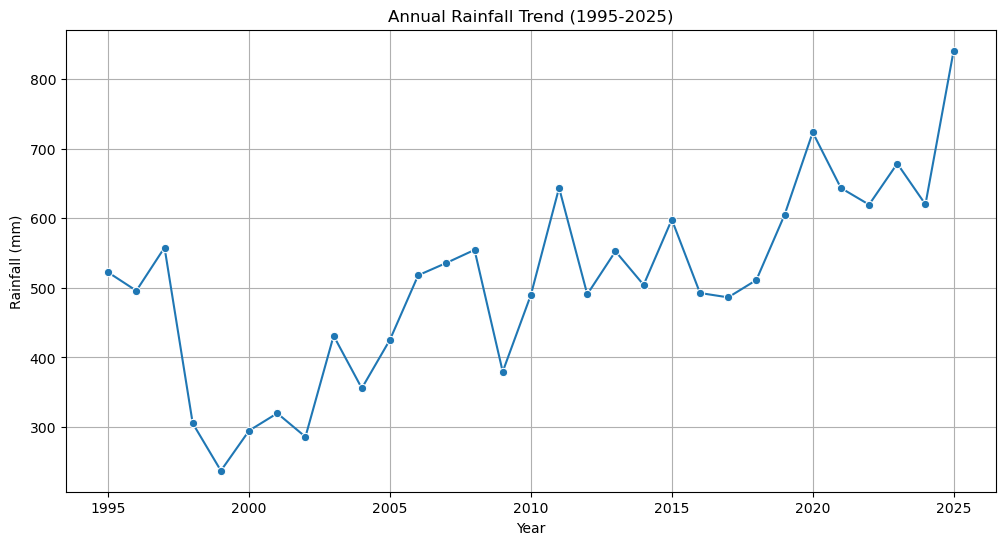

In [6]:
annual_rain = df.groupby('year')['rainfall_mm'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=annual_rain, x='year', y='rainfall_mm', marker='o')
plt.title('Annual Rainfall Trend (1995-2025)')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Year')
plt.grid(True)
plt.show()


C:\Users\offic\AppData\Local\Temp\ipykernel_13128\3402008228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_avg, x='month', y='rainfall_mm', palette='Blues_d')


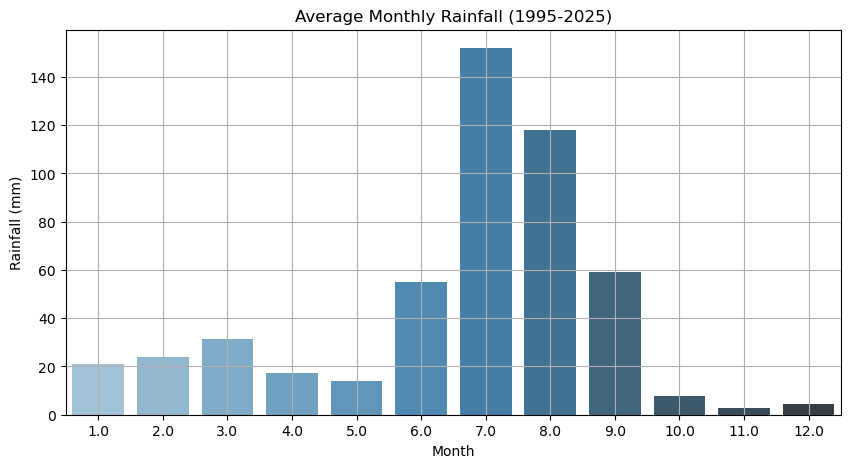

In [7]:
monthly_avg = df.groupby('month')['rainfall_mm'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_avg, x='month', y='rainfall_mm', palette='Blues_d')
plt.title('Average Monthly Rainfall (1995-2025)')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Month')
plt.grid(True)
plt.show()


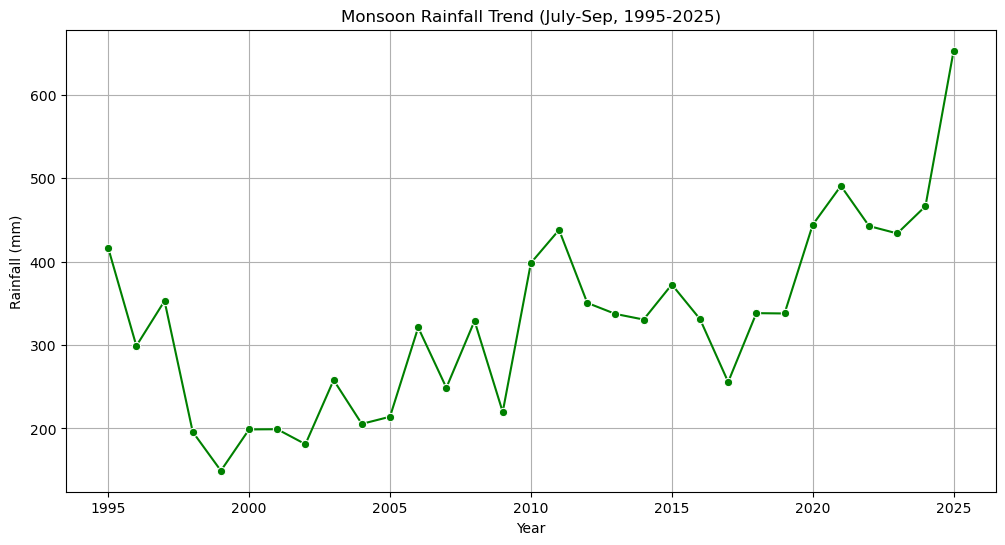

In [8]:
monsoon = df[df['month'].isin([7,8,9])].groupby('year')['rainfall_mm'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=monsoon, x='year', y='rainfall_mm', marker='o', color='green')
plt.title('Monsoon Rainfall Trend (July-Sep, 1995-2025)')
plt.ylabel('Rainfall (mm)')
plt.xlabel('Year')
plt.grid(True)
plt.show()


C:\Users\offic\AppData\Local\Temp\ipykernel_13128\718519112.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_std, x='month', y='rainfall_mm', palette='Reds_d')


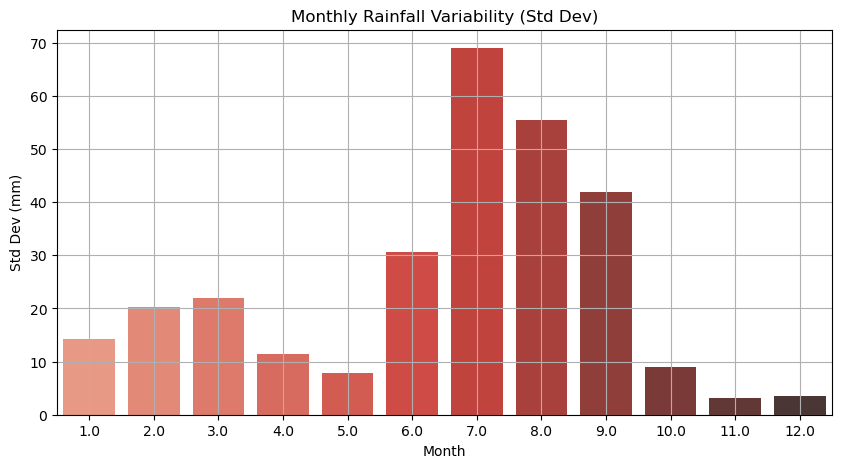

In [11]:
monthly_std = df.groupby('month')['rainfall_mm'].std().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_std, x='month', y='rainfall_mm', palette='Reds_d')
plt.title('Monthly Rainfall Variability (Std Dev)')
plt.ylabel('Std Dev (mm)')
plt.xlabel('Month')
plt.grid(True)
plt.show()


In [12]:
extreme_years = annual_rain.sort_values('rainfall_mm', ascending=False).head(5)
extreme_years_dry = annual_rain.sort_values('rainfall_mm').head(5)
extreme_months = df.sort_values('rainfall_mm', ascending=False).head(5)
extreme_months_dry = df.sort_values('rainfall_mm').head(5)

print("Top 5 Wettest Years:\n", extreme_years)
print("\nTop 5 Driest Years:\n", extreme_years_dry)
print("\nTop 5 Wettest Months:\n", extreme_months)
print("\nTop 5 Driest Months:\n", extreme_months_dry)


Top 5 Wettest Years:
       year  rainfall_mm         MA3
30  2025.0   841.083205  713.335290
25  2020.0   723.656080  613.331751
28  2023.0   678.794050  647.408903
16  2011.0   643.931977  504.513663
26  2021.0   643.687866  657.444701

Top 5 Driest Years:
      year  rainfall_mm         MA3
4  1999.0   237.157379  366.838561
7  2002.0   285.865012  300.141093
5  2000.0   294.787966  279.083312
3  1998.0   305.304592  453.106946
6  2001.0   319.770301  283.905215

Top 5 Wettest Months:
      system:index  month  rainfall_mm    year  \
366           366    7.0   354.963997  2025.0   
342           342    7.0   276.172649  2023.0   
330           330    7.0   263.924297  2022.0   
318           318    7.0   249.113692  2021.0   
367           367    8.0   224.637164  2025.0   

                                       .geo     anomaly  
366  {"type":"MultiPoint","coordinates":[]}  312.698154  
342  {"type":"MultiPoint","coordinates":[]}  233.906806  
330  {"type":"MultiPoint","coordinate

In [13]:
annual_rain.to_csv('Annual_Rainfall_Trend.csv', index=False)
monthly_avg.to_csv('Monthly_Average_Rainfall.csv', index=False)
df.to_csv('Rainfall_Anomalies.csv', index=False)
